# 4. Inventory Optimization — Supply-Constrained Allocation Simulation

## Research Question

In the seafood processing industry, where supply uncertainty due to climate
change and ocean environment shifts is becoming the norm, **how should a
small-to-medium enterprise allocate scarce inventory to maximize
profitability?**

This notebook implements a **counterfactual simulation** comparing two
inventory allocation strategies at **weekly granularity** for higher
precision:

1. **FCFS (First-Come, First-Served)** -- conventional, non-prioritized
2. **Proposed Priority Allocation** -- LTV-based dynamic allocation
   prioritizing "Royal Customers"

Using training data (2015-2023) and validation data (2024), we demonstrate
that the proposed strategy yields significant gross profit improvement
under supply shortage scenarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

FIGURES_DIR = os.path.join("..", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

## 4.1 Load & Prepare Data

In [2]:
# --- Sales data ---
df = pd.read_csv("../data/sample_sales_data.csv")
df["date"] = pd.to_datetime(df["date"])
df_clean = df[df["sales_amount"] > 0].copy()

# --- Market supply data (monthly) ---
df_market = pd.read_csv("../data/market_supply_data.csv")
df_market["date"] = pd.to_datetime(df_market["date"])

# --- Customer clusters (from Notebook 02) ---
clusters = pd.read_csv("../data/customer_clusters.csv")

print(f"Sales data : {len(df_clean):,} records")
print(f"Market data: {len(df_market)} monthly records")
print(f"Clusters   : {len(clusters)} customers")

Sales data : 79,935 records
Market data: 120 monthly records
Clusters   : 276 customers


## 4.2 Reconstruct Customer Segments

Re-derive clustering to ensure full pipeline reproducibility.

In [3]:
CUTOFF_DATE = pd.to_datetime("2024-01-01")
df_hist = df_clean[df_clean["date"] < CUTOFF_DATE].copy()

# --- RFM calculation ---
NOW = CUTOFF_DATE
rfm = df_hist.groupby("customer_code").agg(
    recency=("date", lambda x: (NOW - x.max()).days),
    frequency=("invoice_no", "nunique"),
    monetary=("gross_profit", "sum"),
).reset_index()

# --- B2B/B2C heuristic (simplified) ---
order_stats = (df_hist.groupby(["customer_code", "invoice_no"])["quantity"]
               .sum().reset_index()
               .groupby("customer_code")["quantity"].mean()
               .reset_index().rename(columns={"quantity": "avg_order_qty"}))
rfm = pd.merge(rfm, order_stats, on="customer_code", how="left").fillna(0)

rfm["is_b2b"] = (
    ((rfm["frequency"] >= 10) & (rfm["avg_order_qty"] >= 10)) |
    ((rfm["frequency"] >= 20)) |
    (rfm["monetary"] >= rfm["monetary"].quantile(0.85))
).astype(int)

# --- Sub-clustering ---
cluster_features = ["recency", "frequency", "monetary"]
all_labels = pd.Series(index=rfm.index, dtype=str)

for segment, k in [("B2B", 3), ("B2C", 4)]:
    mask = rfm["is_b2b"] == (1 if segment == "B2B" else 0)
    X_seg = StandardScaler().fit_transform(rfm.loc[mask, cluster_features].fillna(0))
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_seg)
    all_labels[mask] = [f"{segment}_{l}" for l in labels]

rfm["cluster_label"] = all_labels.values
print(f"Clustering complete: {rfm['cluster_label'].value_counts().to_dict()}")

Clustering complete: {'B2B_0': 115, 'B2C_0': 55, 'B2C_1': 44, 'B2B_1': 30, 'B2C_3': 20, 'B2B_2': 9, 'B2C_2': 3}


## 4.3 Build Weekly Simulation Dataset

We aggregate sales data at **weekly** granularity for higher simulation
precision compared to monthly. Monthly market supply data is distributed
proportionally across the weeks of each month.

In [4]:
# Merge cluster labels into transaction data
df_sim = pd.merge(df_clean, rfm[["customer_code", "cluster_label", "is_b2b", "monetary"]],
                  on="customer_code", how="left")

# Drop rows without cluster assignment
df_sim = df_sim.dropna(subset=["cluster_label"])

# --- Create week-level timestamp (Monday of each week) ---
df_sim["year_week"] = df_sim["date"].dt.to_period("W").apply(lambda x: x.start_time)

# --- Weekly demand by cluster ---
weekly_demand = df_sim.groupby(["year_week", "cluster_label", "is_b2b"]).agg(
    total_demand_qty=("quantity", "sum"),
    total_gross_profit=("gross_profit", "sum"),
    total_revenue=("sales_amount", "sum"),
    n_customers=("customer_code", "nunique"),
).reset_index()

print(f"Weekly demand records: {len(weekly_demand)}")
print(f"Week range: {weekly_demand['year_week'].min().date()} to "
      f"{weekly_demand['year_week'].max().date()}")

Weekly demand records: 2023
Week range: 2014-07-21 to 2025-08-18


In [5]:
# --- Distribute monthly market data to weekly ---
# Each month's supply is divided by the number of weeks in that month
def monthly_to_weekly_market(df_market):
    """Convert monthly market data to weekly by proportional distribution."""
    weekly_records = []

    for _, row in df_market.iterrows():
        year, month = int(row["year"]), int(row["month"])
        month_start = pd.Timestamp(year, month, 1)
        # Get all Monday-start weeks that overlap with this month
        month_end = month_start + pd.offsets.MonthEnd(1)

        # Generate weekly periods for this month
        weeks_in_month = pd.date_range(
            start=month_start - pd.offsets.Week(weekday=0),
            end=month_end,
            freq="W-MON"
        )
        # Filter to weeks that actually overlap with this month
        weeks_in_month = [w for w in weeks_in_month
                          if w >= month_start - pd.Timedelta(days=6) and w <= month_end]
        n_weeks = max(len(weeks_in_month), 1)

        for w in weeks_in_month:
            weekly_records.append({
                "year_week": w,
                "market_volume_kg_weekly": row["market_volume_kg"] / n_weeks,
                "market_value_yen_weekly": row["market_value_yen"] / n_weeks,
                "market_avg_price": row["market_avg_price"],
                "market_volume_kg_monthly": row["market_volume_kg"],
            })

    df_weekly_market = pd.DataFrame(weekly_records)
    # If multiple months map to the same week, take the average
    df_weekly_market = df_weekly_market.groupby("year_week").agg({
        "market_volume_kg_weekly": "mean",
        "market_value_yen_weekly": "mean",
        "market_avg_price": "mean",
        "market_volume_kg_monthly": "mean",
    }).reset_index()
    return df_weekly_market

df_market_weekly = monthly_to_weekly_market(df_market)
print(f"Weekly market records: {len(df_market_weekly)}")

Weekly market records: 523


In [6]:
# --- Merge weekly demand with weekly market data ---
df_sim_base = pd.merge(weekly_demand, df_market_weekly,
                       on="year_week", how="left")
df_sim_base.sort_values("year_week", inplace=True)

print(f"Simulation base (weekly): {len(df_sim_base)} rows")
print(f"Date range: {df_sim_base['year_week'].min().date()} to "
      f"{df_sim_base['year_week'].max().date()}")
print(f"Weeks with market data: {df_sim_base['market_volume_kg_weekly'].notna().sum()}")

Simulation base (weekly): 2023 rows
Date range: 2014-07-21 to 2025-08-18
Weeks with market data: 1821


## 4.4 Supply Shock Detection

Supply shock threshold (weekly): 741 kg/week
Shock weeks identified: 97


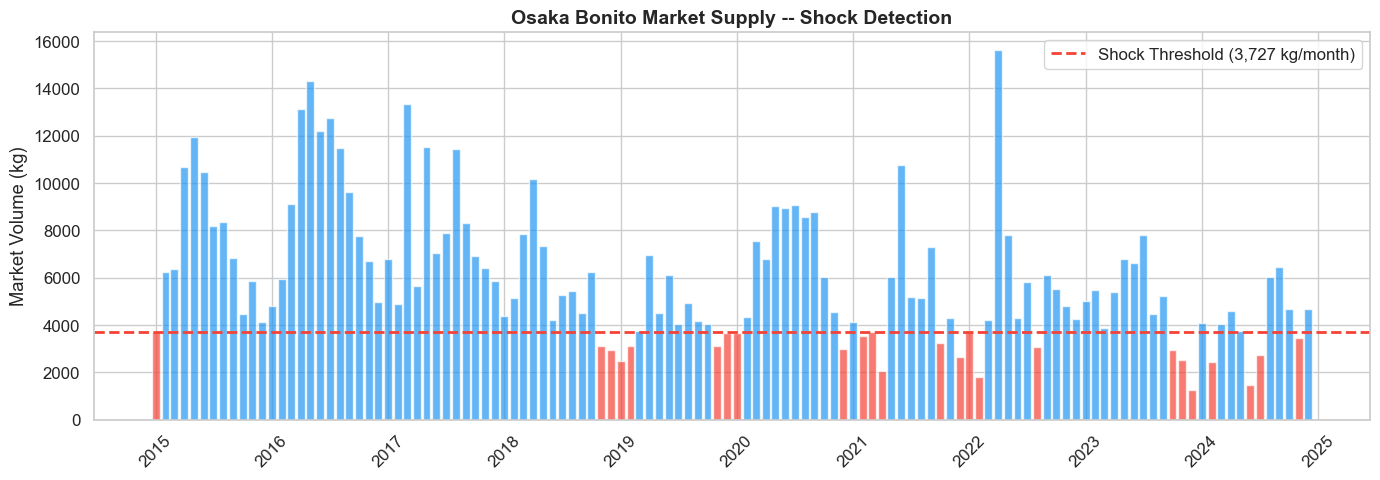

In [7]:
# Define supply shock: weekly market volume in bottom 20th percentile
threshold_volume_weekly = df_sim_base["market_volume_kg_weekly"].quantile(0.20)
df_sim_base["is_supply_shock"] = df_sim_base["market_volume_kg_weekly"] < threshold_volume_weekly

shock_weeks = df_sim_base[df_sim_base["is_supply_shock"]]["year_week"].unique()
print(f"Supply shock threshold (weekly): {threshold_volume_weekly:,.0f} kg/week")
print(f"Shock weeks identified: {len(shock_weeks)}")

# Visualize (using monthly data for cleaner visual)
fig, ax = plt.subplots(figsize=(14, 5))
market_monthly = df_market.copy()
threshold_monthly = df_market["market_volume_kg"].quantile(0.20)
market_monthly["is_shock"] = market_monthly["market_volume_kg"] < threshold_monthly

colors = ["#F44336" if s else "#2196F3" for s in market_monthly["is_shock"]]
ax.bar(market_monthly["date"], market_monthly["market_volume_kg"], width=25,
       color=colors, alpha=0.7, edgecolor="white")
ax.axhline(threshold_monthly, color="#F44336", linestyle="--", linewidth=2,
           label=f"Shock Threshold ({threshold_monthly:,.0f} kg/month)")
ax.set_ylabel("Market Volume (kg)")
ax.set_title("Osaka Bonito Market Supply -- Shock Detection", fontweight="bold", fontsize=14)
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_supply_shock.png"), bbox_inches="tight")
plt.show()

## 4.5 Priority Map Definition

In [8]:
# Priority based on average monetary value (higher monetary = higher priority = lower score)
cluster_monetary_avg = rfm.groupby("cluster_label")["monetary"].mean().sort_values(ascending=False)
priority_map = {cluster: i + 1 for i, cluster in enumerate(cluster_monetary_avg.index)}

print("=== Cluster Priority Map (1 = Highest Priority) ===")
for cluster, priority in sorted(priority_map.items(), key=lambda x: x[1]):
    avg_m = cluster_monetary_avg[cluster]
    print(f"  Priority {priority}: {cluster:10s} (avg monetary: {avg_m:,.0f})")

# Apply priority
df_sim_base["priority_score"] = df_sim_base["cluster_label"].map(priority_map)

=== Cluster Priority Map (1 = Highest Priority) ===
  Priority 1: B2B_2      (avg monetary: 83,285,319)
  Priority 2: B2B_0      (avg monetary: 3,223,921)
  Priority 3: B2B_1      (avg monetary: 919,595)
  Priority 4: B2C_2      (avg monetary: 322,619)
  Priority 5: B2C_3      (avg monetary: 73,977)
  Priority 6: B2C_0      (avg monetary: 31,004)
  Priority 7: B2C_1      (avg monetary: 14,120)


## 4.6 Weekly Allocation Simulation Function

In [9]:
def simulate_allocation_weekly(df_sim_weekly, alpha, strategy, priority_map):
    """
    Simulate inventory allocation under supply constraint at WEEKLY granularity.

    Parameters
    ----------
    df_sim_weekly : pd.DataFrame
        Weekly demand data with weekly market supply info.
    alpha : float
        Supply ratio (0.0 to 1.0). 1.0 = full supply, 0.5 = half supply.
    strategy : str
        'FCFS' (First-Come, First-Served) or 'Proposed' (priority-based).
    priority_map : dict
        Cluster label -> priority score mapping (lower = higher priority).

    Returns
    -------
    total_profit : float
        Total gross profit achieved during the simulation period.
    weekly_results : list of dict
        Per-week allocation details including fulfillment rates.
    """
    total_profit = 0
    weekly_results = []

    # Filter to 2024 for validation
    df_2024 = df_sim_weekly[
        (df_sim_weekly["year_week"] >= pd.to_datetime("2024-01-01")) &
        (df_sim_weekly["year_week"] <= pd.to_datetime("2024-12-31"))
    ].copy()

    for yw, week_data in df_2024.groupby("year_week"):
        # Get weekly market supply
        market_vol_weekly = week_data["market_volume_kg_weekly"].iloc[0]
        if pd.isna(market_vol_weekly):
            # No market data: pass through actual profit
            total_profit += week_data["total_gross_profit"].sum()
            continue

        # Available supply for this week, constrained by alpha
        available_supply = market_vol_weekly * alpha
        remaining_supply = available_supply
        week_profit = 0
        week_detail = {"year_week": yw, "available_supply": available_supply}
        fulfillment_rates = {}

        # Order processing based on strategy
        if strategy == "FCFS":
            # Alphabetical order simulates "first-come" random arrival
            orders = week_data.sort_values("cluster_label")
        elif strategy == "Proposed":
            orders = week_data.copy()
            orders["priority"] = orders["cluster_label"].map(priority_map)
            orders = orders.sort_values("priority")  # Lower = higher priority
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        for _, row in orders.iterrows():
            cluster = row["cluster_label"]
            demand = row["total_demand_qty"]
            profit = row["total_gross_profit"]

            if demand > 0 and remaining_supply > 0:
                allocated = min(demand, remaining_supply)
                fulfilled_ratio = allocated / demand
                realized_profit = fulfilled_ratio * profit
                week_profit += realized_profit
                remaining_supply -= allocated
                fulfillment_rates[cluster] = fulfilled_ratio
            else:
                fulfillment_rates[cluster] = 0.0 if demand > 0 else 1.0

        total_profit += week_profit
        week_detail["profit"] = week_profit
        week_detail["fulfillment"] = fulfillment_rates
        weekly_results.append(week_detail)

    return total_profit, weekly_results

print("Defined simulate_allocation_weekly()")

Defined simulate_allocation_weekly()


## 4.7 Run Multi-Scenario Simulation

In [10]:
alpha_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []

for alpha in alpha_values:
    for strategy in ["FCFS", "Proposed"]:
        profit, details = simulate_allocation_weekly(df_sim_base, alpha, strategy, priority_map)
        results.append({
            "alpha": alpha,
            "strategy": strategy,
            "total_profit": profit,
            "details": details,
        })

# Build results table
results_df = pd.DataFrame([{
    "Supply Ratio (alpha)": r["alpha"],
    "Strategy": r["strategy"],
    "Total Gross Profit": r["total_profit"],
} for r in results])

# Pivot for comparison
comparison = results_df.pivot(index="Supply Ratio (alpha)", columns="Strategy",
                               values="Total Gross Profit")
comparison["Improvement (JPY)"] = comparison["Proposed"] - comparison["FCFS"]
comparison["Improvement (%)"] = (comparison["Improvement (JPY)"] / comparison["FCFS"] * 100)

print("=" * 80)
print("SIMULATION RESULTS -- FCFS vs Proposed Priority Allocation (2024, Weekly)")
print("=" * 80)
print(comparison.round(0).to_string())

# Highlight alpha=0.7 result
alpha_07 = comparison.loc[0.7]
print(f"\nAt alpha=0.7 (severe shortage):")
print(f"   FCFS Profit    : {alpha_07['FCFS']:,.0f} JPY")
print(f"   Proposed Profit: {alpha_07['Proposed']:,.0f} JPY")
print(f"   Improvement    : {alpha_07['Improvement (JPY)']:,.0f} JPY ({alpha_07['Improvement (%)']:.2f}%)")

SIMULATION RESULTS -- FCFS vs Proposed Priority Allocation (2024, Weekly)
Strategy                    FCFS    Proposed  Improvement (JPY)  Improvement (%)
Supply Ratio (alpha)                                                            
0.5                   20772651.0  24156916.0          3384265.0             16.0
0.6                   24821448.0  28543803.0          3722354.0             15.0
0.7                   28856824.0  32641810.0          3784986.0             13.0
0.8                   32924964.0  36562619.0          3637655.0             11.0
0.9                   36994357.0  40410968.0          3416611.0              9.0
1.0                   40987424.0  44260960.0          3273536.0              8.0

At alpha=0.7 (severe shortage):
   FCFS Profit    : 28,856,824 JPY
   Proposed Profit: 32,641,810 JPY
   Improvement    : 3,784,986 JPY (13.12%)


## 4.8 Results Visualization

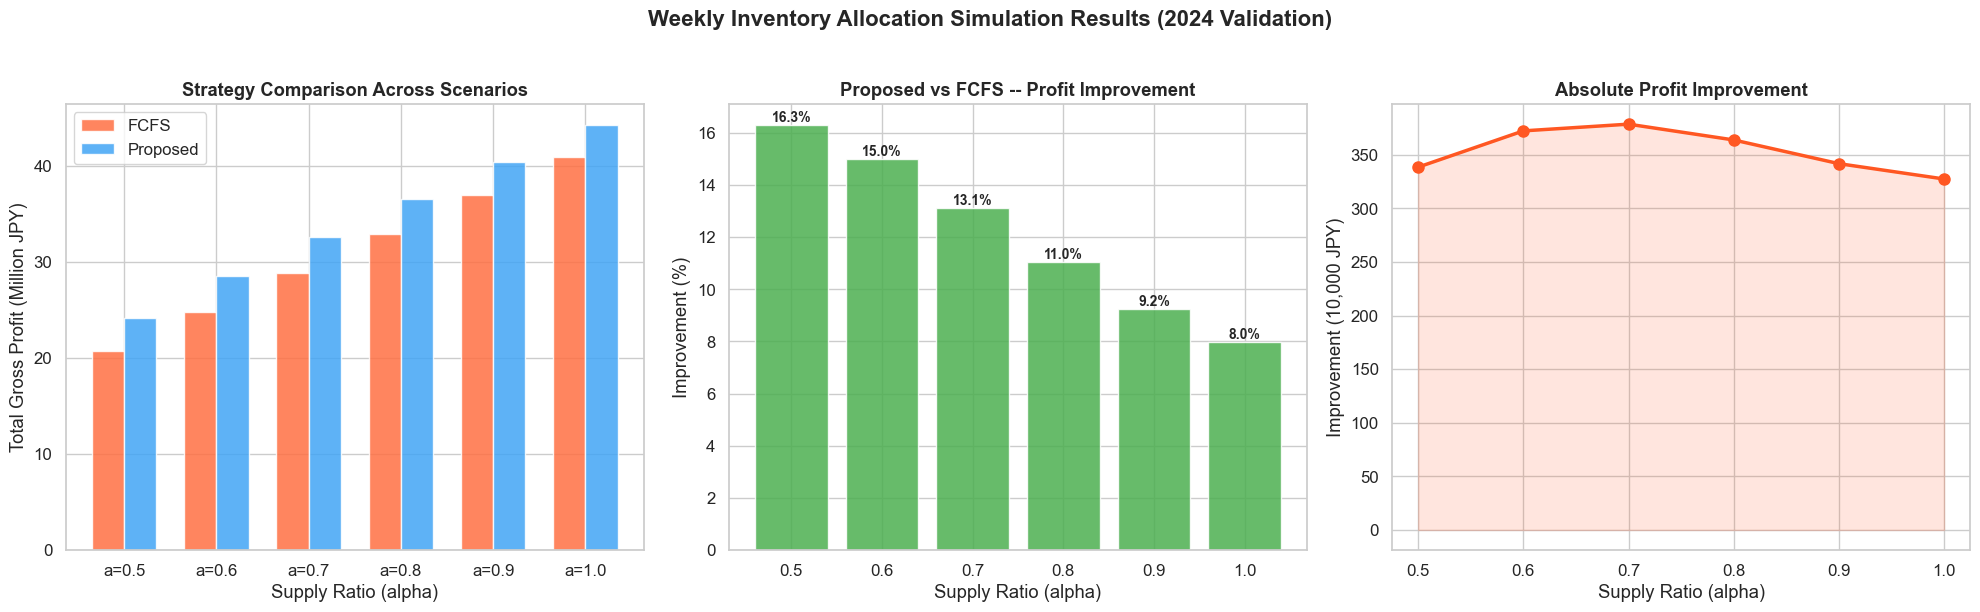

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Chart 1: Strategy comparison across alpha values ---
ax = axes[0]
x = np.arange(len(alpha_values))
width = 0.35

fcfs_profits = [comparison.loc[a, "FCFS"] / 1e6 for a in alpha_values]
prop_profits = [comparison.loc[a, "Proposed"] / 1e6 for a in alpha_values]

bars1 = ax.bar(x - width/2, fcfs_profits, width, label="FCFS", color="#FF7043", alpha=0.85)
bars2 = ax.bar(x + width/2, prop_profits, width, label="Proposed", color="#42A5F5", alpha=0.85)
ax.set_xlabel("Supply Ratio (alpha)")
ax.set_ylabel("Total Gross Profit (Million JPY)")
ax.set_title("Strategy Comparison Across Scenarios", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"a={a}" for a in alpha_values])
ax.legend()

# --- Chart 2: Improvement percentage ---
ax = axes[1]
improvements = [comparison.loc[a, "Improvement (%)"] for a in alpha_values]
colors = ["#4CAF50" if imp > 0 else "#F44336" for imp in improvements]
bars = ax.bar(alpha_values, improvements, width=0.08, color=colors, alpha=0.85, edgecolor="white")
ax.set_xlabel("Supply Ratio (alpha)")
ax.set_ylabel("Improvement (%)")
ax.set_title("Proposed vs FCFS -- Profit Improvement", fontweight="bold")
ax.axhline(0, color="gray", linewidth=0.5)

# Add value labels
for bar, imp in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{imp:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=10)

# --- Chart 3: Improvement in absolute yen ---
ax = axes[2]
imp_yen = [comparison.loc[a, "Improvement (JPY)"] / 1e4 for a in alpha_values]
ax.plot(alpha_values, imp_yen, "o-", color="#FF5722", linewidth=2.5, markersize=8)
ax.fill_between(alpha_values, imp_yen, alpha=0.15, color="#FF5722")
ax.set_xlabel("Supply Ratio (alpha)")
ax.set_ylabel("Improvement (10,000 JPY)")
ax.set_title("Absolute Profit Improvement", fontweight="bold")

plt.suptitle("Weekly Inventory Allocation Simulation Results (2024 Validation)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_simulation_results.png"), bbox_inches="tight")
plt.show()

## 4.9 Cluster-Level Fulfillment Analysis (alpha = 0.7)

=== Average Weekly Fulfillment Rate by Cluster (alpha = 0.7) ===
         FCFS  Proposed  Difference
cluster                            
B2B_2     2.4      74.7        72.3
B2B_0    58.6      10.7       -47.8
B2B_1     0.0       0.0         0.0
B2C_2     4.8       4.8         0.0
B2C_3     4.3       4.3         0.0
B2C_0     0.0       0.0         0.0
B2C_1     0.0       0.0         0.0


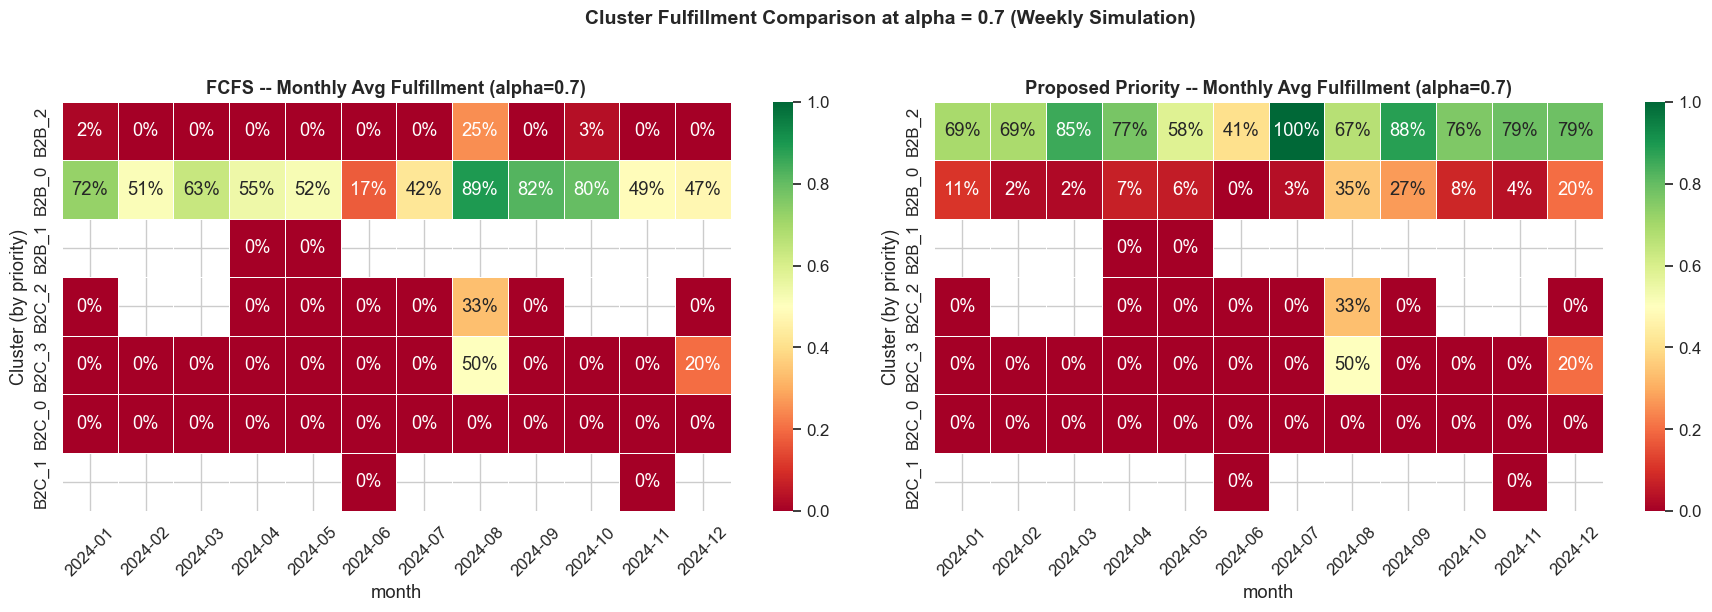

In [12]:
# Extract weekly fulfillment rates at alpha=0.7 for both strategies
def get_fulfillment_df(results, alpha_target, strategy_target):
    for r in results:
        if r["alpha"] == alpha_target and r["strategy"] == strategy_target:
            records = []
            for d in r["details"]:
                for cluster, rate in d["fulfillment"].items():
                    records.append({
                        "year_week": d["year_week"],
                        "cluster": cluster,
                        "fulfillment_rate": rate,
                    })
            return pd.DataFrame(records)
    return pd.DataFrame()

ff_fcfs = get_fulfillment_df(results, 0.7, "FCFS")
ff_prop = get_fulfillment_df(results, 0.7, "Proposed")

# Average fulfillment by cluster
if not ff_fcfs.empty and not ff_prop.empty:
    avg_fcfs = ff_fcfs.groupby("cluster")["fulfillment_rate"].mean()
    avg_prop = ff_prop.groupby("cluster")["fulfillment_rate"].mean()

    fulfillment_comparison = pd.DataFrame({
        "FCFS": avg_fcfs,
        "Proposed": avg_prop,
    }).fillna(0)
    fulfillment_comparison["Difference"] = fulfillment_comparison["Proposed"] - fulfillment_comparison["FCFS"]

    # Sort by priority
    fulfillment_comparison = fulfillment_comparison.reindex(
        sorted(fulfillment_comparison.index, key=lambda x: priority_map.get(x, 99))
    )

    print("=== Average Weekly Fulfillment Rate by Cluster (alpha = 0.7) ===")
    print((fulfillment_comparison * 100).round(1).to_string())

    # --- Heatmap: aggregate by month for readability ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for idx, (ff_data, title, ax) in enumerate([
        (ff_fcfs, "FCFS", axes[0]),
        (ff_prop, "Proposed Priority", axes[1]),
    ]):
        if not ff_data.empty:
            ff_data = ff_data.copy()
            ff_data["month"] = ff_data["year_week"].dt.to_period("M").astype(str)
            # Average weekly fulfillment per month per cluster
            pivot = ff_data.pivot_table(
                index="cluster", columns="month",
                values="fulfillment_rate", aggfunc="mean"
            )
            # Sort by priority
            priority_order = sorted(pivot.index, key=lambda x: priority_map.get(x, 99))
            pivot = pivot.reindex(priority_order)
            sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn",
                        vmin=0, vmax=1, ax=ax, linewidths=0.5)
            ax.set_title(f"{title} -- Monthly Avg Fulfillment (alpha=0.7)", fontweight="bold")
            ax.set_ylabel("Cluster (by priority)")
            ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Cluster Fulfillment Comparison at alpha = 0.7 (Weekly Simulation)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "04_fulfillment_heatmap.png"), bbox_inches="tight")
    plt.show()

## 4.10 Weekly Fulfillment Time Series (alpha = 0.7)

Visualize how fulfillment rates differ week-by-week for the highest-priority
and lowest-priority clusters under both strategies.

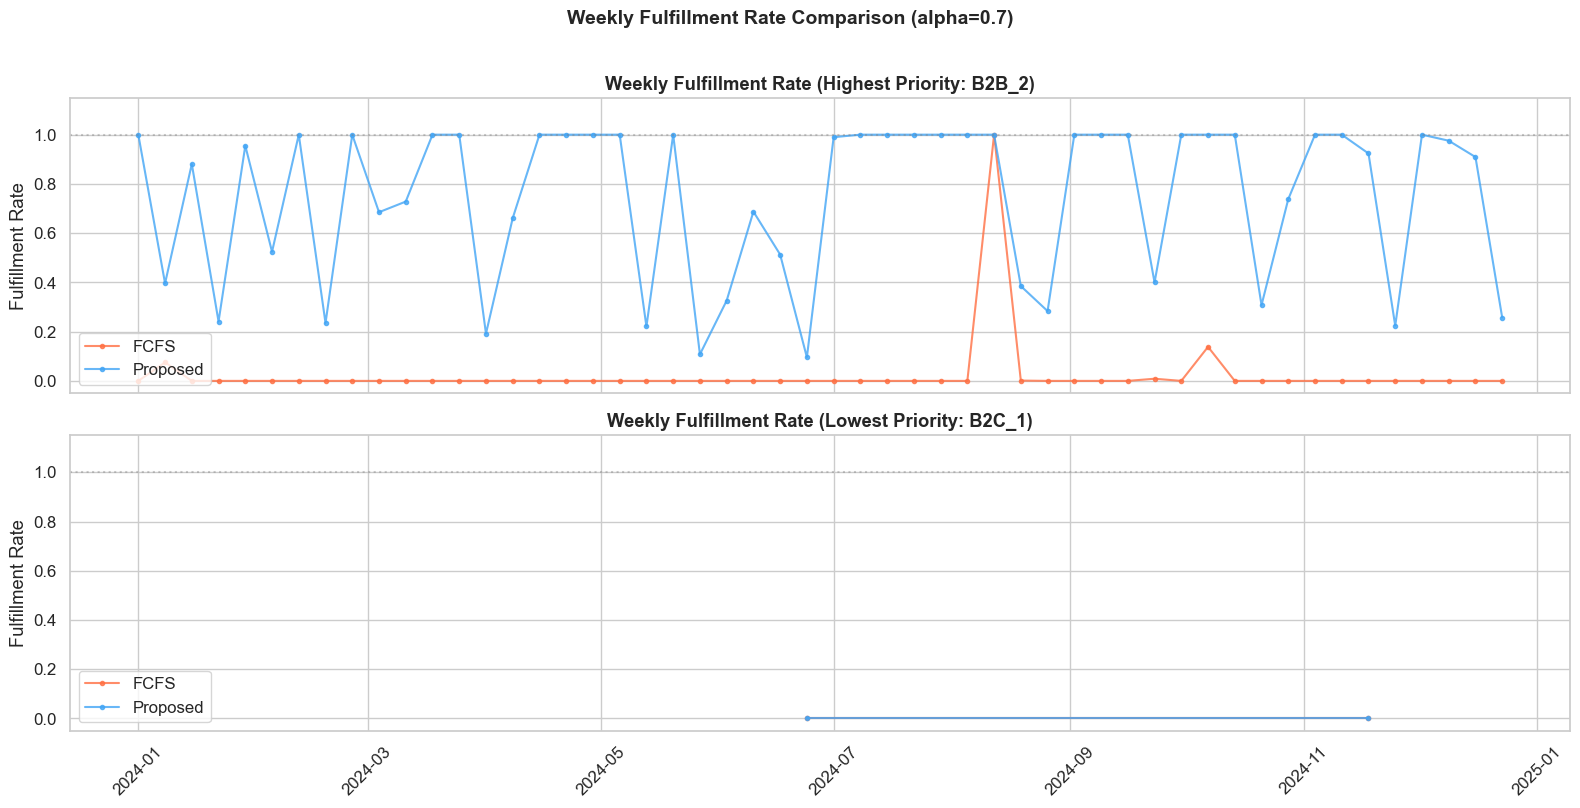

In [13]:
if not ff_fcfs.empty and not ff_prop.empty:
    # Get the highest and lowest priority clusters
    sorted_clusters = sorted(priority_map.items(), key=lambda x: x[1])
    top_cluster = sorted_clusters[0][0]    # Highest priority
    bottom_cluster = sorted_clusters[-1][0]  # Lowest priority

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    for ax, cluster, title_suffix in [
        (axes[0], top_cluster, f"(Highest Priority: {top_cluster})"),
        (axes[1], bottom_cluster, f"(Lowest Priority: {bottom_cluster})"),
    ]:
        fcfs_c = ff_fcfs[ff_fcfs["cluster"] == cluster].sort_values("year_week")
        prop_c = ff_prop[ff_prop["cluster"] == cluster].sort_values("year_week")

        if not fcfs_c.empty:
            ax.plot(fcfs_c["year_week"], fcfs_c["fulfillment_rate"],
                    color="#FF7043", marker=".", linewidth=1.5, alpha=0.8, label="FCFS")
        if not prop_c.empty:
            ax.plot(prop_c["year_week"], prop_c["fulfillment_rate"],
                    color="#42A5F5", marker=".", linewidth=1.5, alpha=0.8, label="Proposed")

        ax.axhline(1.0, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylabel("Fulfillment Rate")
        ax.set_title(f"Weekly Fulfillment Rate {title_suffix}", fontweight="bold")
        ax.legend(loc="lower left")
        ax.set_ylim(-0.05, 1.15)

    axes[1].tick_params(axis="x", rotation=45)
    plt.suptitle("Weekly Fulfillment Rate Comparison (alpha=0.7)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "04_weekly_fulfillment_timeseries.png"),
                bbox_inches="tight")
    plt.show()

## 4.11 Sensitivity Analysis -- Supply Ratio Impact

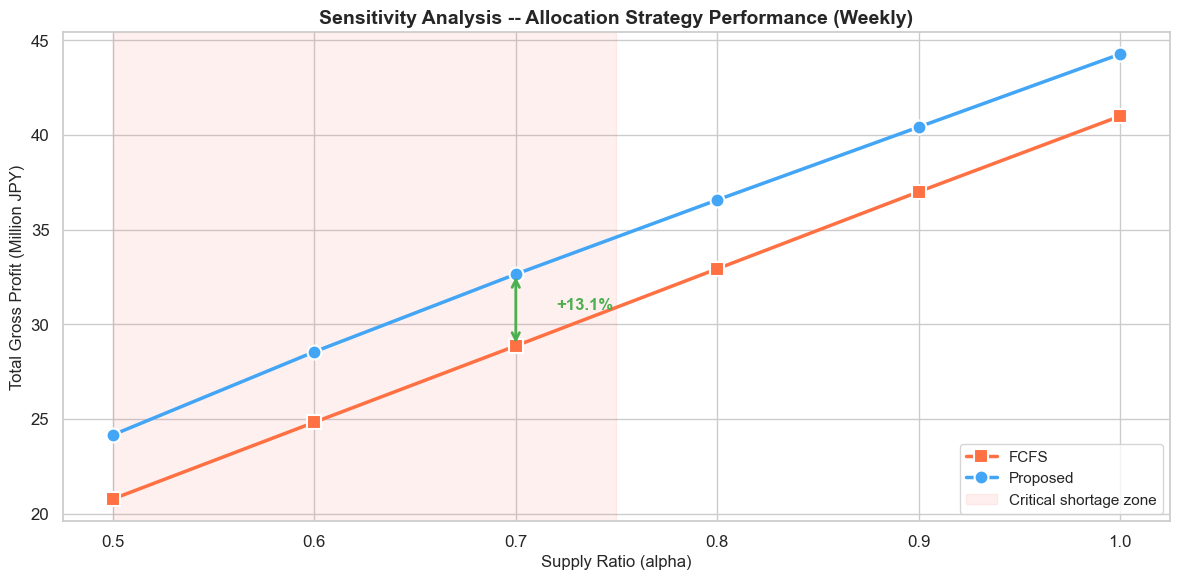

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

for strategy, color, marker in [("FCFS", "#FF7043", "s"), ("Proposed", "#42A5F5", "o")]:
    profits = [comparison.loc[a, strategy] / 1e6 for a in alpha_values]
    ax.plot(alpha_values, profits, f"{marker}-", color=color, linewidth=2.5,
            markersize=10, label=strategy, markeredgecolor="white", markeredgewidth=1.5)

# Shade the critical zone
ax.axvspan(0.5, 0.75, alpha=0.08, color="#F44336", label="Critical shortage zone")
ax.set_xlabel("Supply Ratio (alpha)", fontsize=12)
ax.set_ylabel("Total Gross Profit (Million JPY)", fontsize=12)
ax.set_title("Sensitivity Analysis -- Allocation Strategy Performance (Weekly)",
             fontweight="bold", fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(alpha_values)

# Annotate alpha=0.7 improvement
y_fcfs_07 = comparison.loc[0.7, "FCFS"] / 1e6
y_prop_07 = comparison.loc[0.7, "Proposed"] / 1e6
ax.annotate("", xy=(0.7, y_prop_07), xytext=(0.7, y_fcfs_07),
            arrowprops={"arrowstyle": "<->", "color": "#4CAF50", "lw": 2})
ax.text(0.72, (y_fcfs_07 + y_prop_07) / 2,
        f"+{comparison.loc[0.7, 'Improvement (%)']:.1f}%",
        fontsize=12, fontweight="bold", color="#4CAF50")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_sensitivity_analysis.png"), bbox_inches="tight")
plt.show()

## 4.12 Executive Summary

In [15]:
print("=" * 80)
print("EXECUTIVE SUMMARY -- Inventory Optimization Simulation (Weekly)")
print("=" * 80)
print()
print("BACKGROUND:")
print("  In the seafood processing industry, supply uncertainty from climate change")
print("  and ocean environment shifts is becoming the norm. This study evaluates")
print("  whether a priority-based inventory allocation strategy can improve")
print("  profitability under supply-constrained conditions.")
print()
print("METHODOLOGY:")
print("  - Training data: 2015-2023 sales transactions")
print("  - Validation data: 2024 transactions")
print("  - Granularity: WEEKLY (for higher precision vs monthly)")
print("  - Customer segmentation: B2B/B2C classification + RFM clustering")
print("  - Simulation: Counterfactual comparison of FCFS vs Priority allocation")
print()
print("KEY FINDINGS:")
print()
print("  1. FCFS (conventional) strategy is ECONOMICALLY IRRATIONAL under supply shocks.")
print("     It fails to serve high-value loyal customers, reducing overall profitability.")
print()

alpha_07 = comparison.loc[0.7]
print(f"  2. Proposed Priority Allocation achieves:")
print(f"     - {alpha_07['Improvement (%)']:.2f}% gross profit improvement at alpha=0.7")
print(f"     - {alpha_07['Improvement (JPY)']:,.0f} JPY additional profit (annual)")
print()
print("  3. The strategy functions as 'INTERTEMPORAL ARBITRAGE' -- deliberately")
print("     forgoing short-term sales to allocate scarce inventory to high-LTV")
print("     customers, yielding superior risk-adjusted returns.")
print()

best_alpha = comparison["Improvement (%)"].idxmax()
best_imp = comparison.loc[best_alpha, "Improvement (%)"]
print(f"  4. Maximum improvement: {best_imp:.2f}% at alpha={best_alpha}")
print()
print("CONCLUSION:")
print("  Priority-based allocation is recommended for adoption, particularly")
print("  during supply shortage weeks identified by market data monitoring.")
print("=" * 80)

EXECUTIVE SUMMARY -- Inventory Optimization Simulation (Weekly)

BACKGROUND:
  In the seafood processing industry, supply uncertainty from climate change
  and ocean environment shifts is becoming the norm. This study evaluates
  whether a priority-based inventory allocation strategy can improve
  profitability under supply-constrained conditions.

METHODOLOGY:
  - Training data: 2015-2023 sales transactions
  - Validation data: 2024 transactions
  - Granularity: WEEKLY (for higher precision vs monthly)
  - Customer segmentation: B2B/B2C classification + RFM clustering
  - Simulation: Counterfactual comparison of FCFS vs Priority allocation

KEY FINDINGS:

  1. FCFS (conventional) strategy is ECONOMICALLY IRRATIONAL under supply shocks.
     It fails to serve high-value loyal customers, reducing overall profitability.

  2. Proposed Priority Allocation achieves:
     - 13.12% gross profit improvement at alpha=0.7
     - 3,784,986 JPY additional profit (annual)

  3. The strategy functi

In [16]:
# Save final results
comparison.to_csv("../results/simulation_results.csv")
print("Results saved to: ../results/simulation_results.csv")

Results saved to: ../results/simulation_results.csv
